In [12]:
import os
import numpy as np
os.environ["KERAS_BACKEND"] = "torch"

In [13]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import keras
import tensorflow as tf
import pathlib
import keras_hub
import random

print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: True
Device Name: NVIDIA GeForce RTX 5050 Laptop GPU


### MNIST

#### Load Dataset & data preprocessing

In [3]:
# Load Data
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))
train_images = train_images.astype("float64") / 255.0
test_images = test_images.astype("float64") / 255.0

#### Model & Train

In [5]:
input = keras.layers.Input(shape=(28, 28, 1))
x = keras.layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(input)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(32, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(64, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Conv2D(128, kernel_size=4, padding='valid', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.GlobalAvgPool2D()(x) # x = layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)
output = keras.layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=input, outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 64)       │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 327,242 (1.25 MB)

 Trainable params: 326,410 (1.25 MB)

 Non-trainable params: 832 (3.25 KB)

In [6]:
annealer = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    patience=3,
    verbose=1,
    factor=0.5,
    min_lr=0.00001
)



In [7]:

class SampleCount(keras.metrics.Metric):
    def __init__(self, name="Sample Count", **kwargs):
        super().__init__(name=name, **kwargs)
        self.total_samples = 0

    def update_state(self, y_true, y_pred, sample_weight=None):
        num_samples = len(y_pred)
        self.total_samples += num_samples

    # You use the result() method to return the current value of the metric
    def result(self):
        return self.total_samples

    # expose a way to reset the metric state without having to reinstantiate it for new epoch
    def reset_state(self):
        self.total_samples = 0.


In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", SampleCount]
)

hist = model.fit(train_images, train_labels, epochs=1, batch_size=256, validation_split=0.2, callbacks=[annealer])

188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - Sample Count: 48000.0000 - accuracy: 0.9185 - loss: 0.2706 - val_Sample Count: 12000.0000 - val_accuracy: 0.1527 - val_loss: 4.6591 - learning_rate: 0.0010


In [9]:
model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - Sample Count: 10000.0000 - accuracy: 0.1426 - loss: 4.6605


[4.660515785217285, 0.14259999990463257, 10000.0]

In [10]:
hist.history.keys()

dict_keys(['Sample Count', 'accuracy', 'loss', 'val_Sample Count', 'val_accuracy', 'val_loss', 'learning_rate'])

### Dogs vs Cats

In [11]:
new_base_dir = pathlib.Path(r"C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\DLRL\BOOKS\1\chapter8\dogs_vs_cats_small")
batch_size = 16
image_size = (200, 200)

In [12]:
train_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "train", image_size=image_size, batch_size=batch_size)
validation_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "validation", image_size=image_size, batch_size=batch_size)
test_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "test", image_size=image_size, batch_size=batch_size)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


data batch shape: (16, 200, 200, 3)
labels batch shape: (16,)


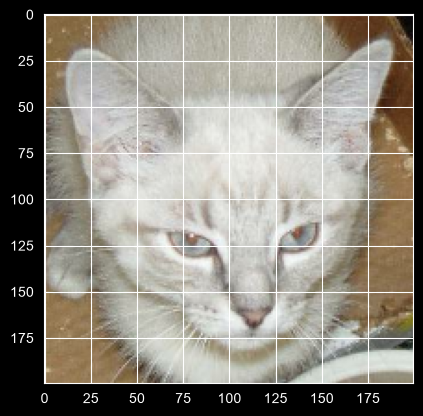

In [13]:
for data_batch, labels_batch in train_dataset:
    plt.imshow(data_batch[0]/255)
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break
plt.show()


In [14]:
inputs = keras.Input(shape=(200, 200, 3))
x = keras.layers.Rescaling(1.0 / 255)(inputs)
#x = keras.layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
#x = keras.layers.BatchNormalization()(x)
#x = keras.layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(x)
#x = keras.layers.BatchNormalization()(x)
#x = keras.layers.Conv2D(32, kernel_size=5, strides=2, padding='same', activation='relu')(x)
#x = keras.layers.BatchNormalization()(x)
#x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(64, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(64, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
#x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(128, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(128, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
#x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(256, kernel_size=3, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Conv2D(256, kernel_size=5, strides=2, padding='same', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
#x = keras.layers.Dropout(0.4)(x)
x = keras.layers.Conv2D(512, kernel_size=5, padding='valid', activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 200, 200, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 200, 200, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 100, 100, 64)   │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100, 100, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 100, 100, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 50, 50, 128)    │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 50, 50, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 50, 50, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 25, 25, 256)    │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,581,505 (25.11 MB)

 Trainable params: 6,577,793 (25.09 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [15]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [16]:
history = model.fit(train_dataset, epochs=20, validation_data=validation_dataset)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5326 - loss: 1.7623

KeyboardInterrupt: 

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

### Fine Tuning

In [14]:
"""
Steps for fine-tuning a network are as follows:

1. Get Base Model and Freeze the base network.

2. Add your custom network on top of an already trained base network.

3 Train the part you added.

4 Unfreeze the base network. (Some Last Few Layers or Full Base Layers)

5 Jointly train both these layers and the part you added.

"""

'\nSteps for fine-tuning a network are as follows:\n\n1. Get Base Model and Freeze the base network.\n\n2. Add your custom network on top of an already trained base network.\n\n3 Train the part you added.\n\n4 Unfreeze the base network. (Some Last Few Layers or Full Base Layers)\n\n5 Jointly train both these layers and the part you added.\n\n'

#### Load Dataset and Data Augmentation

In [15]:
new_base_dir = pathlib.Path(r"C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\DLRL\BOOKS\1\chapter8\dogs_vs_cats_small")
batch_size = 16
image_size = (200, 200)

In [16]:
train_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "train", image_size=image_size, batch_size=batch_size)
validation_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "validation", image_size=image_size, batch_size=batch_size)
test_dataset = keras.utils.image_dataset_from_directory(new_base_dir / "test", image_size=image_size, batch_size=batch_size)

Found 3000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [17]:
num_batches = sum(1 for _ in train_dataset)
print(f"Total number of Training batches: {num_batches}")
print(f"Total number of Training Images: {num_batches*batch_size}")

num_batches = sum(1 for _ in validation_dataset)
print(f"Total number of Validation batches: {num_batches}")
print(f"Total number of Validation Images: {num_batches*batch_size}")

num_batches = sum(1 for _ in test_dataset)
print(f"Total number of Test batches: {num_batches}")
print(f"Total number of Test Images: {num_batches*batch_size}")

Total number of Training batches: 188
Total number of Training Images: 3008
Total number of Validation batches: 63
Total number of Validation Images: 1008
Total number of Test batches: 63
Total number of Test Images: 1008


In [18]:
data_augmentation_layers = [
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.2),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    keras.layers.RandomBrightness(factor=0.2),
    keras.layers.RandomContrast(factor=0.2)
]

def data_augmentation(images, targets):
    random.shuffle(data_augmentation_layers)
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets

expanded_dataset = train_dataset.flat_map(lambda images, targets: tf.data.Dataset.from_tensors((images, targets)).repeat(10))
augmented_train_dataset = expanded_dataset.map(data_augmentation, num_parallel_calls=8)
augmented_train_dataset = augmented_train_dataset.prefetch(tf.data.AUTOTUNE)

In [19]:
num_batches = sum(1 for _ in augmented_train_dataset)
print(f"Total number of batches: {num_batches}")
print(f"Total number of Images: {num_batches*batch_size}")

Total number of batches: 1880
Total number of Images: 30080


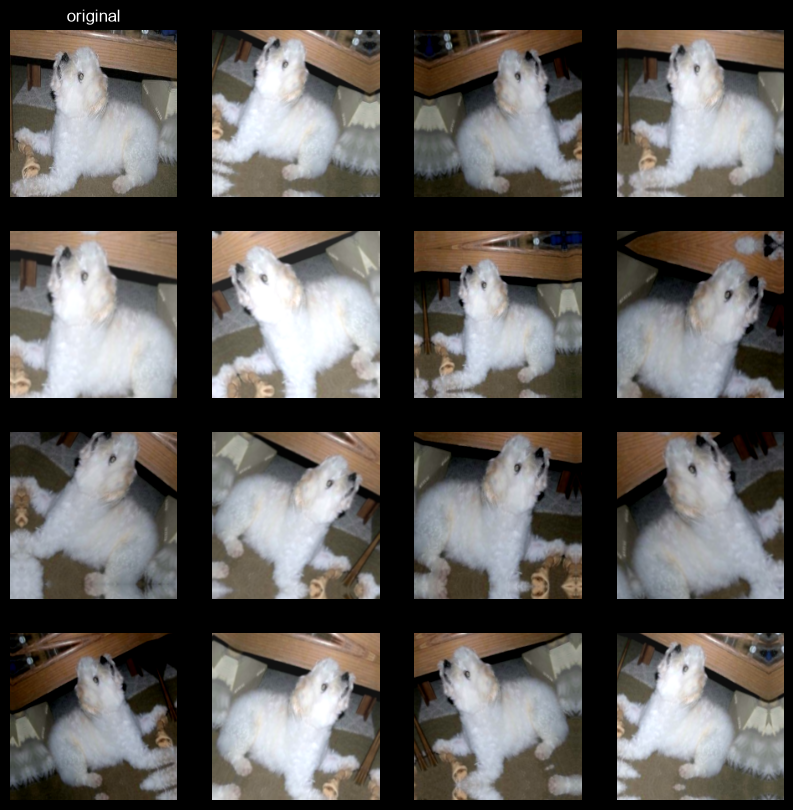

In [20]:
def data_augmentation1(images, targets):
    aug = ["Flip", "Rotation", "Zoom"]
    for layer in data_augmentation_layers:
        images = layer(images)
    return images, targets, aug

plt.figure(figsize=(10, 10))
for image_batch, _ in train_dataset.take(1):
    image = image_batch[0]
    ax = plt.subplot(4, 4, 1)
    plt.imshow(image/255)
    plt.title("original")
    plt.axis("off")
    for i in range(15):
        augmented_image, _, aug = data_augmentation1(image, None)
        augmented_image = keras.ops.convert_to_numpy(augmented_image)
        ax = plt.subplot(4, 4, i+2)
        plt.imshow(augmented_image.astype("uint8"))
        plt.axis("off")

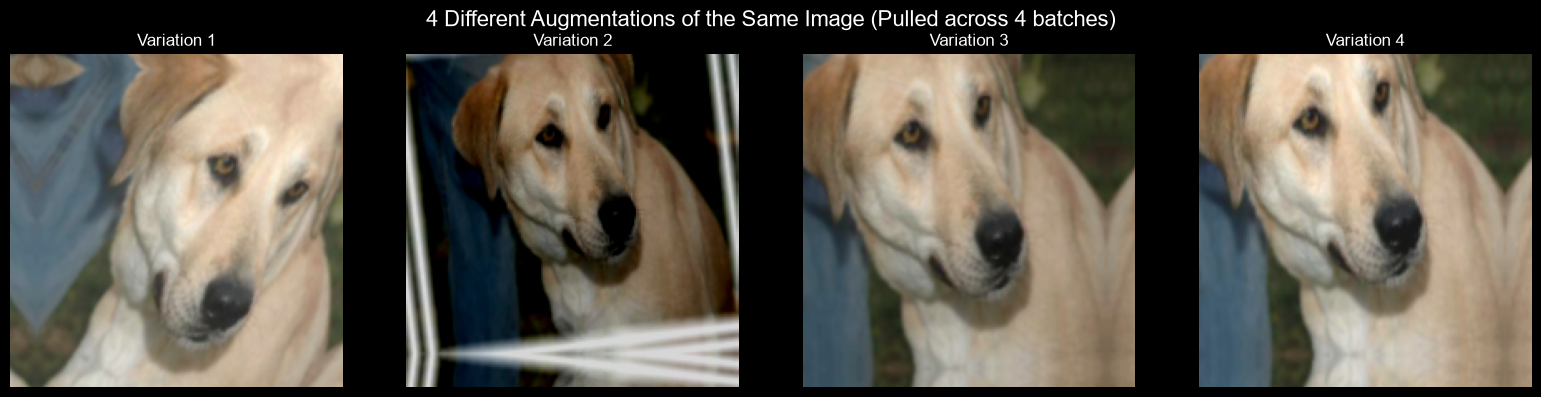

In [21]:
dataset_iterator = iter(augmented_train_dataset)
batch_1_imgs, _ = next(dataset_iterator)
batch_2_imgs, _ = next(dataset_iterator)
batch_3_imgs, _ = next(dataset_iterator)
batch_4_imgs, _ = next(dataset_iterator)
variations = [batch_1_imgs[0], batch_2_imgs[0], batch_3_imgs[0], batch_4_imgs[0]]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("4 Different Augmentations of the Same Image (Pulled across 4 batches)", fontsize=16)
for i, img_tensor in enumerate(variations):
    img = img_tensor.numpy()
    if img.max() > 1.0 and img.dtype != 'uint8':
        img = img.astype("uint8")
    axes[i].imshow(img)
    axes[i].set_title(f"Variation {i+1}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [22]:
preprocessor = keras.Sequential([
    keras.layers.Resizing(180, 180, interpolation="bilinear", crop_to_aspect_ratio=True),
    keras.layers.Rescaling(scale=1.0 / 127.5, offset=-1.0)
])

#### STEP 1 : Base Model

In [23]:
# Instantiating the Xception convolutional base
conv_base = keras_hub.models.Backbone.from_preset("xception_41_imagenet", trainable=False)
conv_base.trainable = False

In [24]:
conv_base

<XceptionBackbone name=xception_backbone, built=True>

In [25]:
conv_base.layers

[<InputLayer name=input_layer, built=True>,
 <Conv2D name=block1_conv1, built=True>,
 <BatchNormalization name=block1_conv1_bn, built=True>,
 <Activation name=block1_conv1_act, built=True>,
 <Conv2D name=block1_conv2, built=True>,
 <BatchNormalization name=block1_conv2_bn, built=True>,
 <Activation name=block1_conv2_act, built=True>,
 <SeparableConv2D name=block2_sepconv1, built=True>,
 <BatchNormalization name=block2_sepconv1_bn, built=True>,
 <Activation name=block2_sepconv2_act, built=True>,
 <SeparableConv2D name=block2_sepconv2, built=True>,
 <BatchNormalization name=block2_sepconv2_bn, built=True>,
 <Conv2D name=block2_residual_conv, built=True>,
 <MaxPooling2D name=block2_pool, built=True>,
 <BatchNormalization name=block2_residual_bn, built=True>,
 <Add name=block2_residual_add, built=True>,
 <Activation name=block3_sepconv1_act, built=True>,
 <SeparableConv2D name=block3_sepconv1, built=True>,
 <BatchNormalization name=block3_sepconv1_bn, built=True>,
 <Activation name=block3_

In [26]:
conv_base.summary()

Model: "xception_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer[0][0] │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_residual_co… │ (None, None,      │      8,192 │ block1_conv2_act… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_residual_bn  │ (None, None,      │        512 │ block2_residual_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_residual_add │ (None, None,      │          0 │ block2_pool[0][0… │
│ (Add)               │ None, 128)        │            │ block2_residual_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ block2_residual_

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [27]:
conv_base.layers[1].input

<KerasTensor shape=(None, None, None, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [28]:
conv_base.layers[1].output

<KerasTensor shape=(None, None, None, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>

In [29]:
conv_base.layers[1].weights

[<Variable path=block1_conv1/kernel, shape=(3, 3, 3, 32), dtype=float32, value=[[[[ 4.01871502e-01  6.77069500e-02 -9.92160812e-02 -2.40881741e-01
      4.94409263e-01 -1.35092044e+00 -7.53455386e-02 -1.15802072e-01
      2.54089713e-01  4.12381589e-01 -2.02945337e-01 -5.65736771e-01
      1.53094187e-01 -5.43646663e-02  9.78396833e-02 -2.72699267e-01
     -9.39905122e-02  3.93782228e-01  3.33525687e-01  2.95914084e-01
     -3.14331800e-02 -1.99261308e-01  1.59772888e-01 -3.25841278e-01
     -1.50597319e-01 -7.27500841e-02  1.80662051e-02  3.05232316e-01
      8.96351188e-02  2.89342284e-01 -2.50950217e-01 -7.65512884e-01]
    [ 4.84812856e-02  4.23621461e-02  4.00314759e-03 -3.78118306e-02
     -5.52299500e-01  7.35755444e-01 -3.38940531e-01 -1.09324297e-02
     -8.63540769e-02 -7.23446161e-02 -5.50143421e-01 -5.00105917e-01
      2.29335129e-01  2.17402652e-01 -1.51911721e-01 -3.03186446e-01
      1.59955341e-02  7.01382399e-01 -6.02655232e-01 -3.59203607e-01
      1.69193089e-01  3.

#### STEP 2 : Modeling

In [30]:
inputs = keras.Input(shape=(200, 200, 3))
x = preprocessor(inputs)
x = conv_base(x)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256)(x)
x = keras.layers.Dropout(0.25)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)


In [31]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_backbone               │ (None, 6, 6, 2048)     │    20,861,480 │
│ (XceptionBackbone)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [32]:
model.layers

[<InputLayer name=input_layer_1, built=True>,
 <Sequential name=sequential_1, built=True>,
 <XceptionBackbone name=xception_backbone, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

#### STEP 3 : Training

In [33]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="finetune_train_without_base.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]
history = model.fit(
    augmented_train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/20
   1880/Unknown 962s 506ms/step - accuracy: 0.9506 - loss: 0.1725

C:\Users\PRASHANTH N\PycharmProjects\MTechSem2\gpu\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1880/1880 ━━━━━━━━━━━━━━━━━━━━ 990s 521ms/step - accuracy: 0.9584 - loss: 0.1332 - val_accuracy: 0.9580 - val_loss: 0.1162
Epoch 2/20
1880/1880 ━━━━━━━━━━━━━━━━━━━━ 1059s 563ms/step - accuracy: 0.9693 - loss: 0.0879 - val_accuracy: 0.9560 - val_loss: 0.1370
Epoch 3/20
 292/1880 ━━━━━━━━━━━━━━━━━━━━ 11:39 441ms/step - accuracy: 0.9724 - loss: 0.0680

#### STEP 4 : Unfreeze Base

In [ ]:
conv_base.trainable = True
for layer in conv_base.layers[:-6]:
    layer.trainable = False


In [ ]:
conv_base.summary()

#### STEP 5 : Train Whole Model

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    metrics=["accuracy"],
)

In [ ]:

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    augmented_train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

#### Evaluate Model

In [ ]:
model = keras.models.load_model("finetune_train_without_base.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

In [ ]:
model = keras.models.load_model("fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

In [ ]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()